# 03b — Modelagem LSTM (Regressão)

Objetivo: prever o **valor de fechamento** (Close) da PETR4.SA usando modelos LSTM de regressão.

**Abordagem:** O target é o **retorno percentual** do dia seguinte `(Close_t+1 / Close_t) - 1`,
que é estacionário e invariante à escala de preço. O preço absoluto é reconstruído
multiplicando `Close_t × (1 + retorno_previsto)`.

**Etapas:**
- **A**: Baseline LSTM (regressão)
- **B**: 4 variações arquiteturais (B1-B4)
- **C**: Otimização Optuna
- **D**: Modelo final — treino, avaliação no teste e salvamento

**Métricas:** MAE, RMSE, MAPE, R², Acurácia Direcional

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import logging, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import tensorflow as tf
import optuna

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from src.utils.mlflow_utils import setup_mlflow, DEFAULT_TRACKING_URI
from src.utils.serialization import save_model, save_metrics
import joblib


logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.21.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Carregar features e preços
df_features = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
petr4_clean = pd.read_csv('../data/processed/petr4_clean.csv', index_col=0, parse_dates=True)

# Alinhar índices
common_idx = df_features.index.intersection(petr4_clean.index)
df_features = df_features.loc[common_idx]
close_prices = petr4_clean.loc[common_idx, 'Close']

# Target de regressão: RETORNO percentual do dia seguinte
# return_t = (Close_t+1 / Close_t) - 1
close_next = close_prices.shift(-1)
target_return = (close_next / close_prices - 1).dropna()

# Alinhar features com target
df_features = df_features.loc[target_return.index]
close_aligned = close_prices.loc[target_return.index]  # Close_t (para reconstruir preço)

print(f"Features: {df_features.shape}")
print(f"Target (return t→t+1): {target_return.shape}")
print(f"Período: {df_features.index.min().date()} a {df_features.index.max().date()}")
print(f"\nTarget returns — min: {target_return.min():.4f}, max: {target_return.max():.4f}, "
      f"mean: {target_return.mean():.6f}, std: {target_return.std():.4f}")
print(f"Close prices — min: R${close_aligned.min():.2f}, max: R${close_aligned.max():.2f}")

Features: (4145, 75)
Target (return t→t+1): (4145,)
Período: 2008-06-18 a 2026-05-07

Target returns — min: -0.2970, max: 0.2222, mean: 0.000788, std: 0.0284
Close prices — min: R$1.10, max: R$49.34


In [4]:
# Divisão temporal 70/15/15
n = len(df_features)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_feat_train = df_features.iloc[:train_end]
X_feat_val = df_features.iloc[train_end:val_end]
X_feat_test = df_features.iloc[val_end:]

y_train_raw = target_return.iloc[:train_end].values
y_val_raw = target_return.iloc[train_end:val_end].values
y_test_raw = target_return.iloc[val_end:].values

# Close prices de cada split (para reconstruir preço absoluto na avaliação)
close_train = close_aligned.iloc[:train_end].values
close_val = close_aligned.iloc[train_end:val_end].values
close_test = close_aligned.iloc[val_end:].values

# Guardar datas para referência
test_dates = df_features.iloc[val_end:].index

# Normalizar features (scaler fitado no treino)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_feat_train)
X_val_scaled = scaler_X.transform(X_feat_val)
X_test_scaled = scaler_X.transform(X_feat_test)

# Normalizar target (retornos — distribuição estacionária)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_raw.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

print(f"Train: {X_train_scaled.shape[0]} | Val: {X_val_scaled.shape[0]} | Test: {X_test_scaled.shape[0]}")
print(f"Train return stats — mean: {y_train_raw.mean():.6f}, std: {y_train_raw.std():.4f}")
print(f"Val return stats   — mean: {y_val_raw.mean():.6f}, std: {y_val_raw.std():.4f}")
print(f"Test return stats  — mean: {y_test_raw.mean():.6f}, std: {y_test_raw.std():.4f}")

Train: 2901 | Val: 622 | Test: 622
Train return stats — mean: 0.000368, std: 0.0312
Val return stats   — mean: 0.002275, std: 0.0236
Test return stats  — mean: 0.001258, std: 0.0163


In [5]:
# Construir sequências 3D
WINDOW_SIZE = 60

def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(window_size, len(X)):
        X_seq.append(X[i - window_size:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

# Ajustar arrays de referência para corresponder às sequências
test_dates = test_dates[WINDOW_SIZE:]
close_val_seq = close_val[WINDOW_SIZE:]      # Close_t para cada amostra de validação
close_test_seq = close_test[WINDOW_SIZE:]    # Close_t para cada amostra de teste
y_val_raw_seq = y_val_raw[WINDOW_SIZE:]      # Retorno real (validação)
y_test_raw_seq = y_test_raw[WINDOW_SIZE:]    # Retorno real (teste)

# Preço real do dia seguinte (Close_t+1) para avaliação em R$
y_val_price = close_val_seq * (1 + y_val_raw_seq)    # Close_t * (1 + return) = Close_t+1
y_test_price = close_test_seq * (1 + y_test_raw_seq)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"Input shape: {X_train.shape[1:]}")
print(f"\nPreço real teste — min: R${y_test_price.min():.2f}, max: R${y_test_price.max():.2f}")

Train: X=(2841, 60, 75), y=(2841,)
Val:   X=(562, 60, 75), y=(562,)
Test:  X=(562, 60, 75), y=(562,)
Input shape: (60, 75)

Preço real teste — min: R$25.78, max: R$49.34


## Funções Auxiliares — Arquiteturas, Treinamento e Métricas de Regressão

In [6]:
def _l2(val):
    return regularizers.l2(val) if val > 0 else None

# ── Arquiteturas (saída linear para regressão) ──

def build_baseline_reg(input_shape, lstm1_units=128, lstm2_units=64, dense_units=32,
                       dropout_lstm=0.3, dropout_dense=0.2, use_batchnorm=True, l2_reg=1e-4):
    reg = _l2(l2_reg)
    inp = layers.Input(shape=input_shape, name='input')
    x = layers.LSTM(lstm1_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_1')(inp)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_1')(x)
    x = layers.LSTM(lstm2_units, return_sequences=False, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_2')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_2')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = layers.Dropout(dropout_dense, name='dropout_3')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)
    return Model(inputs=inp, outputs=out, name='baseline_lstm_reg')

def build_attention_reg(input_shape, lstm1_units=128, lstm2_units=64, dense_units=32,
                        dropout_lstm=0.3, dropout_dense=0.2, use_batchnorm=True, l2_reg=1e-4):
    reg = _l2(l2_reg)
    inp = layers.Input(shape=input_shape, name='input')
    x = layers.LSTM(lstm1_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_1')(inp)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_1')(x)
    x = layers.LSTM(lstm2_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_2')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_2')(x)
    att = layers.MultiHeadAttention(num_heads=4, key_dim=lstm2_units // 4, name='attention')(x, x)
    x = layers.Add(name='residual')([x, att])
    x = layers.LayerNormalization(name='layer_norm')(x)
    x = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = layers.Dropout(dropout_dense, name='dropout_3')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)
    return Model(inputs=inp, outputs=out, name='attention_lstm_reg')

def build_conv1d_lstm_reg(input_shape, conv_filters=64, conv_kernel=3, lstm1_units=128, lstm2_units=64,
                          dense_units=32, dropout_lstm=0.3, dropout_dense=0.2, use_batchnorm=True, l2_reg=1e-4):
    reg = _l2(l2_reg)
    inp = layers.Input(shape=input_shape, name='input')
    x = layers.Conv1D(conv_filters, conv_kernel, activation='relu', padding='same', kernel_regularizer=reg, name='conv1d')(inp)
    x = layers.MaxPooling1D(pool_size=2, name='maxpool')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_conv')(x)
    x = layers.LSTM(lstm1_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_1')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_1')(x)
    x = layers.LSTM(lstm2_units, return_sequences=False, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_2')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_2')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = layers.Dropout(dropout_dense, name='dropout_3')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)
    return Model(inputs=inp, outputs=out, name='conv1d_lstm_reg')

def build_bidirectional_reg(input_shape, lstm1_units=128, lstm2_units=64, dense_units=32,
                            dropout_lstm=0.3, dropout_dense=0.2, use_batchnorm=True, l2_reg=1e-4):
    reg = _l2(l2_reg)
    inp = layers.Input(shape=input_shape, name='input')
    x = layers.Bidirectional(layers.LSTM(lstm1_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg), name='bilstm_1')(inp)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_1')(x)
    x = layers.Bidirectional(layers.LSTM(lstm2_units, return_sequences=False, kernel_regularizer=reg, recurrent_regularizer=reg), name='bilstm_2')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_2')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = layers.Dropout(dropout_dense, name='dropout_3')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)
    return Model(inputs=inp, outputs=out, name='bidirectional_lstm_reg')

def build_lstm_gru_reg(input_shape, lstm_units=128, gru_units=64, dense_units=32,
                       dropout_lstm=0.3, dropout_dense=0.2, use_batchnorm=True, l2_reg=1e-4):
    reg = _l2(l2_reg)
    inp = layers.Input(shape=input_shape, name='input')
    x = layers.LSTM(lstm_units, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg, name='lstm_1')(inp)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_1')(x)
    x = layers.GRU(gru_units, return_sequences=False, kernel_regularizer=reg, recurrent_regularizer=reg, name='gru_1')(x)
    if use_batchnorm: x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(dropout_lstm, name='dropout_2')(x)
    x = layers.Dense(dense_units, activation='relu', kernel_regularizer=reg, name='dense_1')(x)
    x = layers.Dropout(dropout_dense, name='dropout_3')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)
    return Model(inputs=inp, outputs=out, name='lstm_gru_reg')

# Registro
ARCH_REG = {
    'baseline': build_baseline_reg,
    'attention': build_attention_reg,
    'conv1d_lstm': build_conv1d_lstm_reg,
    'bidirectional': build_bidirectional_reg,
    'lstm_gru': build_lstm_gru_reg,
}

def build_reg_model(arch_name, input_shape, **kwargs):
    return ARCH_REG[arch_name](input_shape=input_shape, **kwargs)

print(f"Arquiteturas de regressão disponíveis: {list(ARCH_REG.keys())}")

Arquiteturas de regressão disponíveis: ['baseline', 'attention', 'conv1d_lstm', 'bidirectional', 'lstm_gru']


In [7]:
# ── Métricas de regressão ──

def compute_regression_metrics(y_true_price, y_pred_price):
    """Calcula MAE, RMSE, MAPE e R² em escala de preço (R$)."""
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = np.sqrt(mean_squared_error(y_true_price, y_pred_price))
    mask = y_true_price != 0
    mape = np.mean(np.abs((y_true_price[mask] - y_pred_price[mask]) / y_true_price[mask])) * 100
    r2 = r2_score(y_true_price, y_pred_price)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

def compute_return_metrics(y_true_ret, y_pred_ret):
    """Métricas nos retornos (para diagnóstico)."""
    mae = mean_absolute_error(y_true_ret, y_pred_ret)
    rmse = np.sqrt(mean_squared_error(y_true_ret, y_pred_ret))
    r2 = r2_score(y_true_ret, y_pred_ret)
    direction_acc = np.mean(np.sign(y_true_ret) == np.sign(y_pred_ret)) * 100
    return {'MAE_ret': mae, 'RMSE_ret': rmse, 'R2_ret': r2, 'Direction_Acc': direction_acc}

def print_metrics(metrics, label=''):
    sep = chr(9472) * 40
    print(f"\n{sep}")
    if label:
        print(f"  {label}")
    print(f"  MAE:  R$ {metrics['MAE']:.4f}")
    print(f"  RMSE: R$ {metrics['RMSE']:.4f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  R²:   {metrics['R2']:.4f}")
    if 'Direction_Acc' in metrics:
        print(f"  Dir Acc: {metrics['Direction_Acc']:.1f}%")
    print(sep)

In [8]:
# ── Função de treinamento para regressão ──

def train_reg_model(model, X_tr, y_tr, X_v, y_v, run_name,
                    learning_rate=0.001, batch_size=64, epochs=200,
                    logs_dir='../logs_reg', models_dir='../models_reg',
                    tags=None, log_to_mlflow=True):
    """Treina modelo de regressão com MSE + integração MLflow/TensorBoard."""
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    Path(logs_dir).mkdir(parents=True, exist_ok=True)
    Path(models_dir).mkdir(parents=True, exist_ok=True)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(os.path.join(models_dir, f'{run_name}_best.keras'),
                        monitor='val_loss', save_best_only=True, verbose=0),
        TensorBoard(log_dir=os.path.join(logs_dir, run_name), histogram_freq=1),
    ]

    params = {
        'architecture': model.name, 'learning_rate': learning_rate,
        'batch_size': batch_size, 'max_epochs': epochs,
        'window_size': X_tr.shape[1], 'n_features': X_tr.shape[2],
        'train_samples': X_tr.shape[0], 'val_samples': X_v.shape[0],
        'task': 'regression', 'target': 'return_pct',
    }
    if tags: params.update({f'tag_{k}': v for k, v in tags.items()})

    if log_to_mlflow:
        if not mlflow.get_tracking_uri() or 'mlruns' in mlflow.get_tracking_uri():
            mlflow.set_tracking_uri(DEFAULT_TRACKING_URI)
        mlflow.set_experiment('lstm_financial_petr4_regression')
        with mlflow.start_run(run_name=run_name):
            mlflow.log_params(params)
            if tags: mlflow.set_tags(tags)
            history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                                epochs=epochs, batch_size=batch_size,
                                callbacks=callbacks, verbose=1)
            best_epoch = np.argmin(history.history['val_loss'])
            mlflow.log_metric('best_epoch', best_epoch)
            mlflow.log_metric('train_loss', history.history['loss'][best_epoch])
            mlflow.log_metric('val_loss', history.history['val_loss'][best_epoch])
            mlflow.log_metric('train_mae', history.history['mae'][best_epoch])
            mlflow.log_metric('val_mae', history.history['val_mae'][best_epoch])
            mlflow.keras.log_model(model, 'model')
    else:
        history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                            epochs=epochs, batch_size=batch_size,
                            callbacks=callbacks, verbose=1)

    best_epoch = np.argmin(history.history['val_loss'])
    logger.info(f"Melhor época: {best_epoch}, Val Loss: {history.history['val_loss'][best_epoch]:.6f}")
    return model, history.history

In [9]:
# ── Função auxiliar: avaliar modelo (reconstruir preço a partir de retornos) ──

def evaluate_on_split(model, X_v, close_t, y_true_price, y_true_raw_returns):
    """Prediz retornos, reconstrói preços e calcula métricas em R$."""
    y_pred_scaled = model.predict(X_v, verbose=0).flatten()
    y_pred_returns = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Reconstruir preço: Close_t * (1 + predicted_return)
    y_pred_price = close_t * (1 + y_pred_returns)

    # Métricas de preço
    price_metrics = compute_regression_metrics(y_true_price, y_pred_price)

    # Métricas de retorno (diagnóstico)
    ret_metrics = compute_return_metrics(y_true_raw_returns, y_pred_returns)
    price_metrics.update(ret_metrics)

    return price_metrics, y_pred_price

---
## Etapa A — Baseline LSTM (Regressão)

Hiperparâmetros fixos: lr=0.001, batch=64, T=60

In [10]:
input_shape = X_train.shape[1:]  # (60, 75)

model_a = build_reg_model('baseline', input_shape)
model_a.summary()

W0000 00:00:1778626794.411100    3229 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778626794.615482    3229 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13358 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "baseline_lstm_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,737 (612.25 KB)

 Trainable params: 156,353 (610.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
model_a, history_a = train_reg_model(
    model=model_a, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val,
    run_name='reg_A_baseline',
    tags={'stage': 'A', 'architecture': 'baseline', 'task': 'regression'},
)

2026/05/12 20:00:10 INFO mlflow.tracking.fluent: Experiment with name 'lstm_financial_petr4_regression' does not exist. Creating a new experiment.


Epoch 1/200


I0000 00:00:1778626817.150697    3628 cuda_dnn.cc:461] Loaded cuDNN version 92101


45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 1.7832 - mae: 1.0021 - val_loss: 0.6765 - val_mae: 0.5924 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.4299 - mae: 0.8689 - val_loss: 0.6759 - val_mae: 0.5892 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.3576 - mae: 0.8371 - val_loss: 0.6956 - val_mae: 0.6093 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2202 - mae: 0.7815 - val_loss: 0.7188 - val_mae: 0.6245 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.1923 - mae: 0.7716 - val_loss: 0.7273 - val_mae: 0.6296 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1204 - mae: 0.7416 - val_loss: 0.7127 - val_mae: 0.6155 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1.1572 - mae: 0.7504
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45

2026/05/12 20:00:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:00:38 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:00:50,408 - __main__ - INFO - Melhor época: 1, Val Loss: 0.675884


In [12]:
metrics_a, _ = evaluate_on_split(model_a, X_val, close_val_seq, y_val_price, y_val_raw_seq)
print_metrics(metrics_a, 'A — Baseline (Validação)')


────────────────────────────────────────
  A — Baseline (Validação)
  MAE:  R$ 0.2496
  RMSE: R$ 0.3477
  MAPE: 1.83%
  R²:   0.9932
  Dir Acc: 47.5%
────────────────────────────────────────


---
## Etapa B — Teste de Arquiteturas Alternativas

Mesmos hiperparâmetros da Etapa A para comparação justa.

In [13]:
architectures_b = {
    'B1_attention': 'attention',
    'B2_conv1d_lstm': 'conv1d_lstm',
    'B3_bidirectional': 'bidirectional',
    'B4_lstm_gru': 'lstm_gru',
}

results_b = {}

for label, arch_name in architectures_b.items():
    print(f"\n{'='*60}")
    print(f"Treinando {label} ({arch_name})")
    print(f"{'='*60}")

    model_b = build_reg_model(arch_name, input_shape)
    model_b, history_b = train_reg_model(
        model=model_b, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val,
        run_name=f'reg_{label}',
        tags={'stage': 'B', 'architecture': arch_name, 'variant': label, 'task': 'regression'},
    )

    met, _ = evaluate_on_split(model_b, X_val, close_val_seq, y_val_price, y_val_raw_seq)
    print_metrics(met, f'{label} (Validação)')

    results_b[label] = {'metrics': met, 'model': model_b}
    tf.keras.backend.clear_session()


Treinando B1_attention (attention)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 1.1928 - mae: 0.7634 - val_loss: 0.7292 - val_mae: 0.6301 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.0663 - mae: 0.7098 - val_loss: 0.8273 - val_mae: 0.6901 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0662 - mae: 0.7012 - val_loss: 0.7244 - val_mae: 0.6291 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0506 - mae: 0.6990 - val_loss: 0.6764 - val_mae: 0.6033 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0303 - mae: 0.6930 - val_loss: 0.6433 - val_mae: 0.5746 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.0395 - mae: 0.6917 - val_loss: 0.6464 - val_mae: 0.5766 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.0279 - mae: 0.6862 - val_loss: 0.6393 - val_mae: 0

2026/05/12 20:04:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:04:21 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:04:28,847 - __main__ - INFO - Melhor época: 7, Val Loss: 0.639169



────────────────────────────────────────
  B1_attention (Validação)
  MAE:  R$ 0.2424
  RMSE: R$ 0.3412
  MAPE: 1.79%
  R²:   0.9935
  Dir Acc: 51.8%
────────────────────────────────────────

Treinando B2_conv1d_lstm (conv1d_lstm)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 2.1323 - mae: 1.1000 - val_loss: 0.6432 - val_mae: 0.5672 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.5561 - mae: 0.9240 - val_loss: 0.6416 - val_mae: 0.5663 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.3993 - mae: 0.8579 - val_loss: 0.6488 - val_mae: 0.5701 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2924 - mae: 0.8081 - val_loss: 0.6567 - val_mae: 0.5757 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1.2419 - mae: 0.7928 - val_loss: 0.6732 - val_mae: 0.5909 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss

2026/05/12 20:04:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:04:52 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:04:59,547 - __main__ - INFO - Melhor época: 1, Val Loss: 0.641603



────────────────────────────────────────
  B2_conv1d_lstm (Validação)
  MAE:  R$ 0.2389
  RMSE: R$ 0.3385
  MAPE: 1.78%
  R²:   0.9936
  Dir Acc: 55.0%
────────────────────────────────────────

Treinando B3_bidirectional (bidirectional)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 2.2628 - mae: 1.1190 - val_loss: 0.8110 - val_mae: 0.6272 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 1.5980 - mae: 0.9152 - val_loss: 0.7809 - val_mae: 0.6138 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.4394 - mae: 0.8369 - val_loss: 0.8079 - val_mae: 0.6295 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 1.3596 - mae: 0.8139 - val_loss: 0.7985 - val_mae: 0.6179 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.2726 - mae: 0.7725 - val_loss: 0.8040 - val_mae: 0.6249 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step 

2026/05/12 20:05:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:05:48 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:05:55,714 - __main__ - INFO - Melhor época: 14, Val Loss: 0.772510



────────────────────────────────────────
  B3_bidirectional (Validação)
  MAE:  R$ 0.2588
  RMSE: R$ 0.3617
  MAPE: 1.89%
  R²:   0.9927
  Dir Acc: 48.8%
────────────────────────────────────────

Treinando B4_lstm_gru (lstm_gru)
Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 1.8877 - mae: 1.0243 - val_loss: 0.6661 - val_mae: 0.5903 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.3964 - mae: 0.8516 - val_loss: 0.6854 - val_mae: 0.6017 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2742 - mae: 0.8123 - val_loss: 0.6898 - val_mae: 0.6088 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.2059 - mae: 0.7773 - val_loss: 0.6772 - val_mae: 0.5937 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.1549 - mae: 0.7517 - val_loss: 0.6693 - val_mae: 0.5909 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 

2026/05/12 20:06:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:06:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:06:35,722 - __main__ - INFO - Melhor época: 14, Val Loss: 0.664280



────────────────────────────────────────
  B4_lstm_gru (Validação)
  MAE:  R$ 0.2474
  RMSE: R$ 0.3457
  MAPE: 1.83%
  R²:   0.9933
  Dir Acc: 47.7%
────────────────────────────────────────


In [14]:
# Tabela comparativa A + B
comparison = [{'Modelo': 'A - Baseline', **metrics_a}]
for label, res in results_b.items():
    comparison.append({'Modelo': label, **res['metrics']})

df_comp = pd.DataFrame(comparison)
display(df_comp.sort_values('RMSE'))

df_comp.to_csv('../reports/tabela_comparativa_AB_regressao.csv', index=False)

# Melhor modelo por RMSE
best_row = df_comp.sort_values('RMSE').iloc[0]
print(f"\n🏆 Melhor modelo: {best_row['Modelo']} (RMSE=R${best_row['RMSE']:.4f}, R²={best_row['R2']:.4f})")

,Modelo,MAE,RMSE,MAPE,R2,MAE_ret,RMSE_ret,R2_ret,Direction_Acc
2,B2_conv1d_lstm,0.238910,0.338494,1.775807,0.993598,0.017690,0.023833,-0.010216,54.982206
1,B1_attention,0.242390,0.341216,1.785695,0.993495,0.017881,0.023955,-0.020584,51.779359
4,B4_lstm_gru,0.247352,0.345702,1.830683,0.993322,0.018352,0.024456,-0.063735,47.686833
0,A - Baseline,0.249608,0.347705,1.832774,0.993245,0.018404,0.024630,-0.078897,47.508897
3,B3_bidirectional,0.258813,0.361655,1.889379,0.992692,0.018959,0.025202,-0.129605,48.754448



🏆 Melhor modelo: B2_conv1d_lstm (RMSE=R$0.3385, R²=0.9936)


---
## Etapa C — Otimização Optuna (Regressão)

Usar a arquitetura vencedora da etapa anterior. Objetivo: minimizar RMSE na validação.

In [15]:
# Seleção automática da melhor arquitetura
arch_map = {
    'A - Baseline': 'baseline',
    'B1_attention': 'attention',
    'B2_conv1d_lstm': 'conv1d_lstm',
    'B3_bidirectional': 'bidirectional',
    'B4_lstm_gru': 'lstm_gru',
}
best_row = df_comp.sort_values('RMSE').iloc[0]
BEST_ARCH = arch_map[best_row['Modelo']]
print(f"Arquitetura selecionada: {BEST_ARCH} (RMSE=R${best_row['RMSE']:.4f})")

def objective(trial):
    window_size = trial.suggest_categorical('window_size', [30, 45, 60, 90])
    lstm1_units = trial.suggest_int('lstm1_units', 64, 256, step=32)
    lstm2_units = trial.suggest_int('lstm2_units', 32, 128, step=32)
    dense_units = trial.suggest_int('dense_units', 16, 64, step=16)
    dropout_lstm = trial.suggest_float('dropout_lstm', 0.1, 0.5)
    dropout_dense = trial.suggest_float('dropout_dense', 0.1, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)

    # Ajustar window
    current_window = X_train.shape[1]
    if window_size <= current_window:
        X_tr = X_train[:, -window_size:, :]
        X_v = X_val[:, -window_size:, :]
    else:
        X_tr, X_v = X_train, X_val
        window_size = current_window

    inp_shape = (X_tr.shape[1], X_tr.shape[2])

    build_kw = dict(dense_units=dense_units, dropout_lstm=dropout_lstm,
                    dropout_dense=dropout_dense, use_batchnorm=use_batchnorm, l2_reg=l2_reg)
    if BEST_ARCH in ('baseline', 'attention', 'conv1d_lstm', 'bidirectional'):
        build_kw['lstm1_units'] = lstm1_units
        build_kw['lstm2_units'] = lstm2_units
    elif BEST_ARCH == 'lstm_gru':
        build_kw['lstm_units'] = lstm1_units
        build_kw['gru_units'] = lstm2_units

    try:
        model = build_reg_model(BEST_ARCH, inp_shape, **build_kw)
    except Exception as e:
        return float('inf')

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])

    cbs = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0),
    ]

    model.fit(X_tr, y_train, validation_data=(X_v, y_val),
              epochs=100, batch_size=batch_size, verbose=0, callbacks=cbs)

    # Predizer retornos e reconstruir preços para calcular RMSE em R$
    y_pred_s = model.predict(X_v, verbose=0).flatten()
    y_pred_returns = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
    y_pred_price = close_val_seq * (1 + y_pred_returns)
    rmse = np.sqrt(mean_squared_error(y_val_price, y_pred_price))

    # Log MLflow nested
    try:
        with mlflow.start_run(run_name=f'trial_{trial.number:03d}', nested=True):
            mlflow.log_params(trial.params)
            mlflow.log_metric('rmse', rmse)
            mlflow.set_tag('stage', 'C')
    except Exception:
        pass

    tf.keras.backend.clear_session()
    logger.info(f"  Trial {trial.number}: RMSE=R${rmse:.4f}")
    return rmse

print(f"\nIniciando Optuna com 50 trials (minimizar RMSE)...")

Arquitetura selecionada: conv1d_lstm (RMSE=R$0.3385)

Iniciando Optuna com 50 trials (minimizar RMSE)...


In [16]:
if not mlflow.get_tracking_uri() or 'mlruns' in mlflow.get_tracking_uri():
    mlflow.set_tracking_uri(DEFAULT_TRACKING_URI)
mlflow.set_experiment('lstm_financial_petr4_regression')

with mlflow.start_run(run_name='reg_C_optuna'):
    mlflow.set_tag('stage', 'C')
    mlflow.set_tag('architecture', BEST_ARCH)
    mlflow.log_param('n_trials', 50)

    study = optuna.create_study(direction='minimize', study_name=f'lstm_{BEST_ARCH}_reg_optim')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    best_params = study.best_params
    mlflow.log_params({f'best_{k}': v for k, v in best_params.items()})
    mlflow.log_metric('best_rmse', study.best_value)

print(f"\nMelhores hiperparâmetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nMelhor RMSE: R${study.best_value:.4f}")

[I 2026-05-12 20:06:37,983] A new study created in memory with name: lstm_conv1d_lstm_reg_optim
Best trial: 0. Best value: 0.340547:   2%|▏         | 1/50 [00:18<15:19, 18.76s/it]

[I 2026-05-12 20:06:56,742] Trial 0 finished with value: 0.3405472996991727 and parameters: {'window_size': 30, 'lstm1_units': 160, 'lstm2_units': 128, 'dense_units': 16, 'dropout_lstm': 0.48675604293607144, 'dropout_dense': 0.23512424564558276, 'learning_rate': 0.00017230679035516022, 'batch_size': 64, 'use_batchnorm': False, 'l2_reg': 0.000431733721646514}. Best is trial 0 with value: 0.3405472996991727.


2026-05-12 20:07:34,567 - __main__ - INFO -   Trial 1: RMSE=R$0.3643
Best trial: 0. Best value: 0.340547:   4%|▍         | 2/50 [00:56<23:58, 29.98s/it]

[I 2026-05-12 20:07:34,569] Trial 1 finished with value: 0.3642975610001916 and parameters: {'window_size': 45, 'lstm1_units': 192, 'lstm2_units': 128, 'dense_units': 32, 'dropout_lstm': 0.19663830670905125, 'dropout_dense': 0.10217785700174195, 'learning_rate': 0.00024046083754670778, 'batch_size': 128, 'use_batchnorm': True, 'l2_reg': 0.004447201403083073}. Best is trial 0 with value: 0.3405472996991727.


2026-05-12 20:08:38,636 - __main__ - INFO -   Trial 2: RMSE=R$0.3377
Best trial: 2. Best value: 0.33768:   6%|▌         | 3/50 [02:00<35:40, 45.54s/it] 

...

[I 2026-05-12 20:34:05,085] Trial 47 finished with value: 0.3366834473461394 and parameters: {'window_size': 90, 'lstm1_units': 192, 'lstm2_units': 32, 'dense_units': 48, 'dropout_lstm': 0.41589358771745644, 'dropout_dense': 0.15263126175089853, 'learning_rate': 0.003499650780399714, 'batch_size': 32, 'use_batchnorm': False, 'l2_reg': 1.9655301383987727e-05}. Best is trial 37 with value: 0.33579504752727907.


2026-05-12 20:34:57,635 - __main__ - INFO -   Trial 48: RMSE=R$0.3369
Best trial: 37. Best value: 0.335795:  98%|█████████▊| 49/50 [28:19<00:35, 35.46s/it]

[I 2026-05-12 20:34:57,637] Trial 48 finished with value: 0.33693485753778785 and parameters: {'window_size': 90, 'lstm1_units': 224, 'lstm2_units': 96, 'dense_units': 64, 'dropout_lstm': 0.35683790462650167, 'dropout_dense': 0.1654134817250238, 'learning_rate': 0.004434764797236736, 'batch_size': 32, 'use_batchnorm': True, 'l2_reg': 0.009541091017644358}. Best is trial 37 with value: 0.33579504752727907.


2026-05-12 20:35:12,221 - __main__ - INFO -   Trial 49: RMSE=R$0.3367
Best trial: 37. Best value: 0.335795: 100%|██████████| 50/50 [28:34<00:00, 34.28s/it]

[I 2026-05-12 20:35:12,222] Trial 49 finished with value: 0.33674859467376583 and parameters: {'window_size': 60, 'lstm1_units': 192, 'lstm2_units': 64, 'dense_units': 48, 'dropout_lstm': 0.40357158053487246, 'dropout_dense': 0.27173700951467333, 'learning_rate': 0.00688853915570368, 'batch_size': 128, 'use_batchnorm': False, 'l2_reg': 0.0031725894392381055}. Best is trial 37 with value: 0.33579504752727907.

Melhores hiperparâmetros:
  window_size: 90
  lstm1_units: 256
  lstm2_units: 32
  dense_units: 48
  dropout_lstm: 0.47958457484474115
  dropout_dense: 0.3556845500119008
  learning_rate: 0.00809802909787791
  batch_size: 32
  use_batchnorm: True
  l2_reg: 1.6055881041286037e-05

Melhor RMSE: R$0.3358


In [17]:
# Visualização Optuna
import optuna.visualization as vis

fig = vis.plot_optimization_history(study)
fig.show()

fig = vis.plot_param_importances(study)
fig.show()

---
## Etapa D — Modelo Final: Treino, Avaliação no Teste e Salvamento

In [18]:
# Construir modelo final com melhores hiperparâmetros
best_window = best_params.get('window_size', 60)

if best_window <= X_train.shape[1]:
    X_train_final = X_train[:, -best_window:, :]
    X_val_final = X_val[:, -best_window:, :]
    X_test_final = X_test[:, -best_window:, :]
else:
    X_train_final, X_val_final, X_test_final = X_train, X_val, X_test

# Nota: close_test_seq, y_test_price etc. já estão alinhados com X_test
# (mesmo número de amostras), não precisam de ajuste de window

input_shape_final = X_train_final.shape[1:]

build_kw = {
    'dense_units': best_params.get('dense_units', 32),
    'dropout_lstm': best_params.get('dropout_lstm', 0.3),
    'dropout_dense': best_params.get('dropout_dense', 0.2),
    'use_batchnorm': best_params.get('use_batchnorm', True),
    'l2_reg': best_params.get('l2_reg', 1e-4),
}
if BEST_ARCH in ('baseline', 'attention', 'conv1d_lstm', 'bidirectional'):
    build_kw['lstm1_units'] = best_params.get('lstm1_units', 128)
    build_kw['lstm2_units'] = best_params.get('lstm2_units', 64)
elif BEST_ARCH == 'lstm_gru':
    build_kw['lstm_units'] = best_params.get('lstm1_units', 128)
    build_kw['gru_units'] = best_params.get('lstm2_units', 64)

model_final = build_reg_model(BEST_ARCH, input_shape_final, **build_kw)
model_final.summary()

Model: "conv1d_lstm_reg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │        14,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv (BatchNormalization)    │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 256)        │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 30, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 383,201 (1.46 MB)

 Trainable params: 382,497 (1.46 MB)

 Non-trainable params: 704 (2.75 KB)

In [19]:
model_final, history_final = train_reg_model(
    model=model_final,
    X_tr=X_train_final, y_tr=y_train,
    X_v=X_val_final, y_v=y_val,
    run_name='reg_D_modelo_final',
    learning_rate=best_params.get('learning_rate', 0.001),
    batch_size=best_params.get('batch_size', 64),
    tags={'stage': 'D', 'architecture': BEST_ARCH, 'status': 'final', 'task': 'regression'},
)

Epoch 1/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1.3746 - mae: 0.8319 - val_loss: 0.6154 - val_mae: 0.5659 - learning_rate: 0.0081
Epoch 2/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0502 - mae: 0.7057 - val_loss: 0.6081 - val_mae: 0.5609 - learning_rate: 0.0081
Epoch 3/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0326 - mae: 0.6959 - val_loss: 0.6094 - val_mae: 0.5621 - learning_rate: 0.0081
Epoch 4/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0261 - mae: 0.6926 - val_loss: 0.6125 - val_mae: 0.5632 - learning_rate: 0.0081
Epoch 5/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0314 - mae: 0.6921 - val_loss: 0.6250 - val_mae: 0.5711 - learning_rate: 0.0081
Epoch 6/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0338 - mae: 0.6933 - val_loss: 0.6181 - val_mae: 0.5670 - learning_rate: 0.0081
Epoch 7/200
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0068 - mae: 0.6826
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.004049014765

2026/05/12 20:35:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 20:35:40 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026-05-12 20:35:49,644 - __main__ - INFO - Melhor época: 1, Val Loss: 0.608139


In [20]:
# ── Avaliação final no conjunto de TESTE ──

y_pred_test_scaled = model_final.predict(X_test_final).flatten()
y_pred_test_returns = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

# Reconstruir preço: Close_t * (1 + predicted_return)
y_pred_test = close_test_seq * (1 + y_pred_test_returns)

test_metrics = compute_regression_metrics(y_test_price, y_pred_test)
ret_metrics = compute_return_metrics(y_test_raw_seq, y_pred_test_returns)
test_metrics.update(ret_metrics)
print_metrics(test_metrics, 'MODELO FINAL — Conjunto de TESTE')

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

────────────────────────────────────────
  MODELO FINAL — Conjunto de TESTE
  MAE:  R$ 0.3784
  RMSE: R$ 0.5395
  MAPE: 1.17%
  R²:   0.9877
  Dir Acc: 52.3%
────────────────────────────────────────


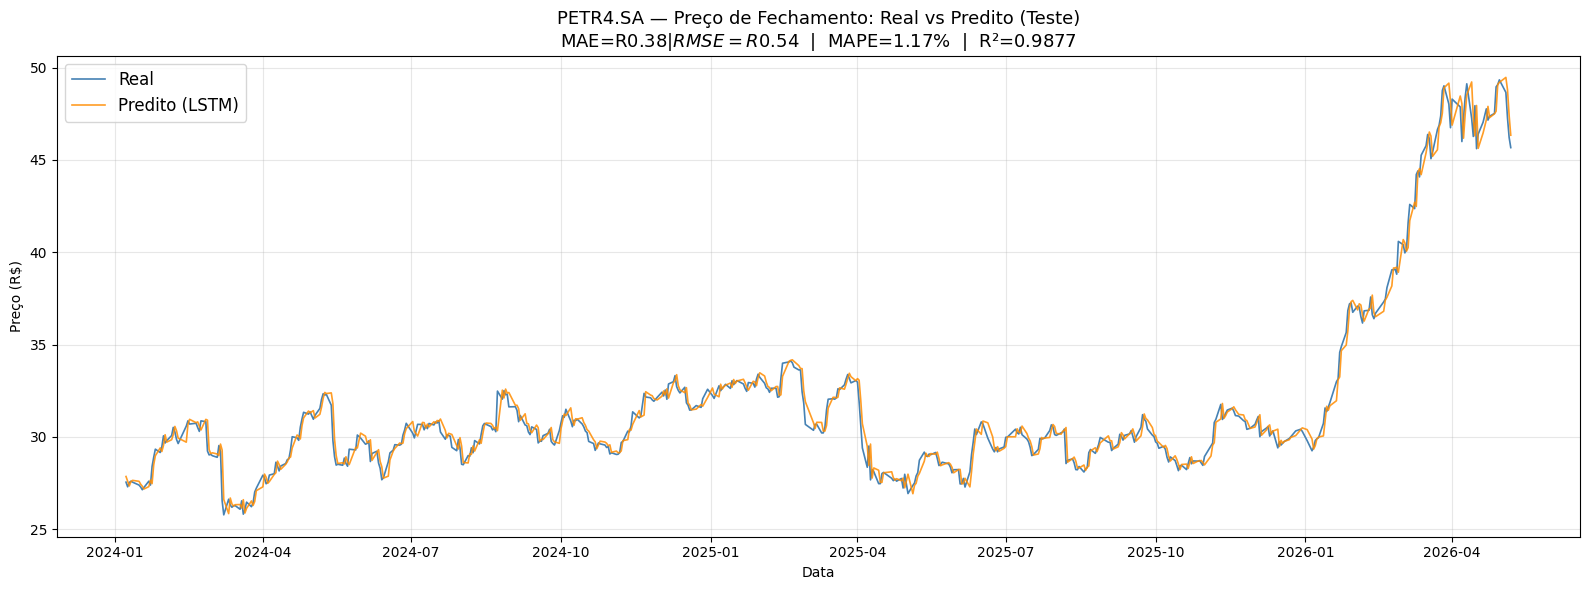

In [21]:
# Gráfico: Preço real vs Predito no teste
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_dates, y_test_price, label='Real', linewidth=1.2, color='steelblue')
ax.plot(test_dates, y_pred_test, label='Predito (LSTM)', linewidth=1.2, color='darkorange', alpha=0.85)
ax.set_title(f'PETR4.SA — Preço de Fechamento: Real vs Predito (Teste)\n'
             f'MAE=R${test_metrics["MAE"]:.2f}  |  RMSE=R${test_metrics["RMSE"]:.2f}  |  '
             f'MAPE={test_metrics["MAPE"]:.2f}%  |  R²={test_metrics["R2"]:.4f}',
             fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('Preço (R$)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('../reports/etapa_D_regressao', exist_ok=True)
plt.savefig('../reports/etapa_D_regressao/real_vs_predito_teste.png', dpi=150, bbox_inches='tight')
plt.show()

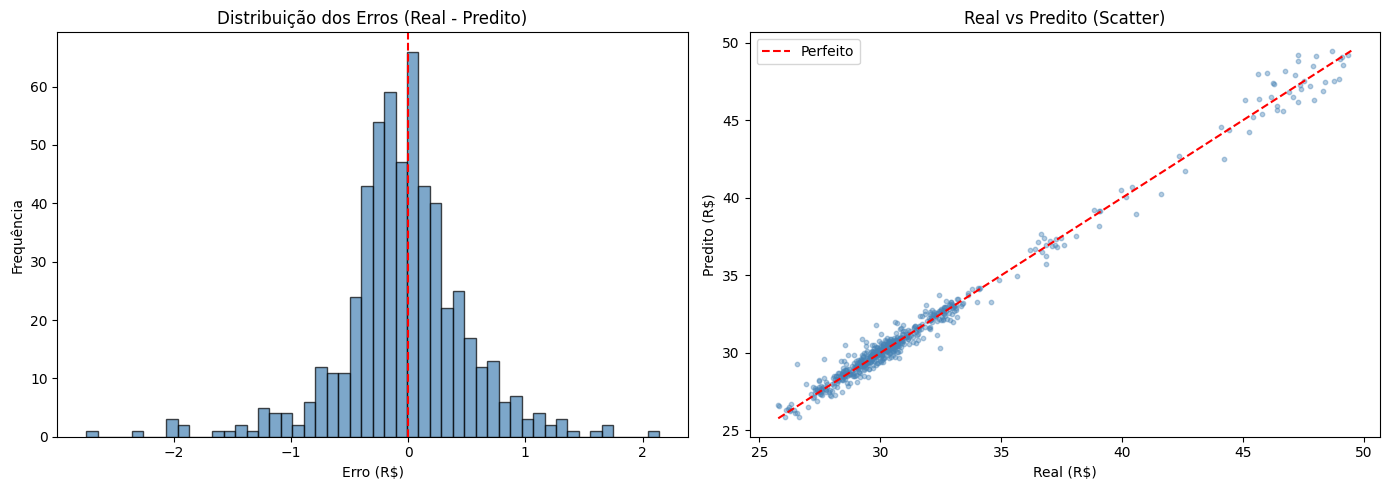

In [22]:
# Gráfico: Distribuição dos erros
errors = y_test_price - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribuição dos Erros (Real - Predito)')
axes[0].set_xlabel('Erro (R$)')
axes[0].set_ylabel('Frequência')

axes[1].scatter(y_test_price, y_pred_test, alpha=0.4, s=10, color='steelblue')
lims = [min(y_test_price.min(), y_pred_test.min()), max(y_test_price.max(), y_pred_test.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfeito')
axes[1].set_title('Real vs Predito (Scatter)')
axes[1].set_xlabel('Real (R$)')
axes[1].set_ylabel('Predito (R$)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/etapa_D_regressao/erros_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Salvar modelo final e artefatos ──
save_model(model_final, '../models/model_regression.keras')
save_metrics(test_metrics, '../models/metrics_regression.json')

# Salvar scalers de regressão
joblib.dump(scaler_X, '../models/scaler_X_regression.pkl')
joblib.dump(scaler_y, '../models/scaler_y_regression.pkl')

# Salvar config
reg_config = {
    'architecture': BEST_ARCH,
    'window_size': int(model_final.input_shape[1]),
    'n_features': int(model_final.input_shape[2]),
    'best_params': {k: (int(v) if isinstance(v, (np.integer,)) else
                        float(v) if isinstance(v, (np.floating,)) else v)
                    for k, v in best_params.items()},
    'test_metrics': {k: v for k, v in test_metrics.items() if isinstance(v, (int, float))},
    'task': 'regression',
    'target': 'return_t_to_t+1',
    'target_description': 'Retorno percentual (Close_t+1/Close_t - 1). Reconstruir preco: Close_t * (1 + pred_return)',
}
with open('../models/regression_config.json', 'w') as f:
    json.dump(reg_config, f, indent=2)

print(f"\n✅ Modelo de regressão salvo com sucesso!")
print(f"   Arquitetura: {BEST_ARCH}")
print(f"   Target: retorno percentual (Close_t+1/Close_t - 1)")
print(f"   Artefatos em: ../models/")
print(f"     - model_regression.keras")
print(f"     - metrics_regression.json")
print(f"     - scaler_X_regression.pkl")
print(f"     - scaler_y_regression.pkl")
print(f"     - regression_config.json")

2026-05-12 20:35:52,321 - src.utils.serialization - INFO - Modelo salvo: ../models/model_regression.keras
2026-05-12 20:35:52,322 - src.utils.serialization - INFO - Métricas salvas: ../models/metrics_regression.json



✅ Modelo de regressão salvo com sucesso!
   Arquitetura: conv1d_lstm
   Target: retorno percentual (Close_t+1/Close_t - 1)
   Artefatos em: ../models/
     - model_regression.keras
     - metrics_regression.json
     - scaler_X_regression.pkl
     - scaler_y_regression.pkl
     - regression_config.json
